# Example

This notebook demonstrates how to delineate valley floors using `valley-floor`.

## Inputs

The core algorithm takes four raster inputs on the same grid:

- **DEM** — raw digital elevation model
- **HAND** — height above nearest drainage
- **channel_network** — reach-labeled raster skeleton
- **subbasins** — reach-labeled subbasin raster (IDs must match channel_network)

These can be produced by any standard hydrology tool. Common options include
[pysheds](https://github.com/mdbartos/pysheds) and
[WhiteboxTools](https://github.com/jblindsay/whitebox-tools).

This notebook uses the optional `prepare_inputs` function, which produces these
inputs from a DEM and vector flowlines using [streamkit](https://github.com/avkoehl/streamkit).
Both the sample data and `prepare_inputs` require the streamkit optional dependency:

```bash
pip install "valley-floor[streamkit] @ git+https://github.com/avkoehl/valley-floor.git"
```

## Entry points

The package provides two functions:

- `map_valley_floor` — returns the valley floor raster only
- `map_valley_floor_detailed` — returns the floor plus diagnostic outputs (region floor, flood floor, slope break points, per-reach HAND thresholds)

This notebook uses `map_valley_floor_detailed`.

## Load sample data

The sample data is a DEM and NHD flowlines for a small watershed in California
(HUC 1805000203). Data is downloaded on first use and cached locally.

In [1]:
import matplotlib.pyplot as plt
from vhs.data import load_sample_data
from xrspatial import hillshade

dem, flowlines = load_sample_data()
hs = hillshade(dem)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Loading sample data from cache at /Users/arthurkoehl/Library/Caches/vhs...


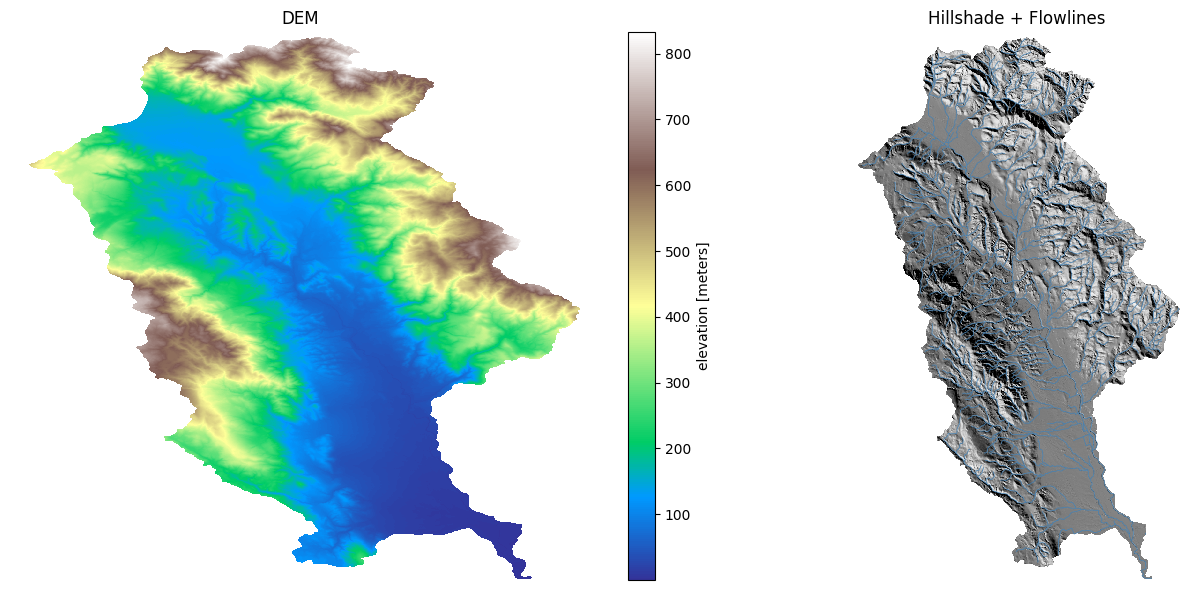

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

dem.plot(ax=axes[0], cmap='terrain', add_colorbar=True)
axes[0].set_title('DEM')
axes[0].set_axis_off()

hs.plot(ax=axes[1], cmap='Greys_r', add_colorbar=False)
flowlines.plot(ax=axes[1], color='steelblue', linewidth=0.5)
axes[1].set_title('Hillshade + Flowlines')
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

## Prepare inputs

`prepare_inputs` runs a streamkit-based hydrological workflow to produce
HAND, a reach-labeled channel network, and subbasins from the DEM and flowlines.
The raw DEM is passed through unchanged — conditioning happens internally.

In [3]:
from vhs import prepare_inputs

dem, hand, channel_network, subbasins = prepare_inputs(dem, flowlines)

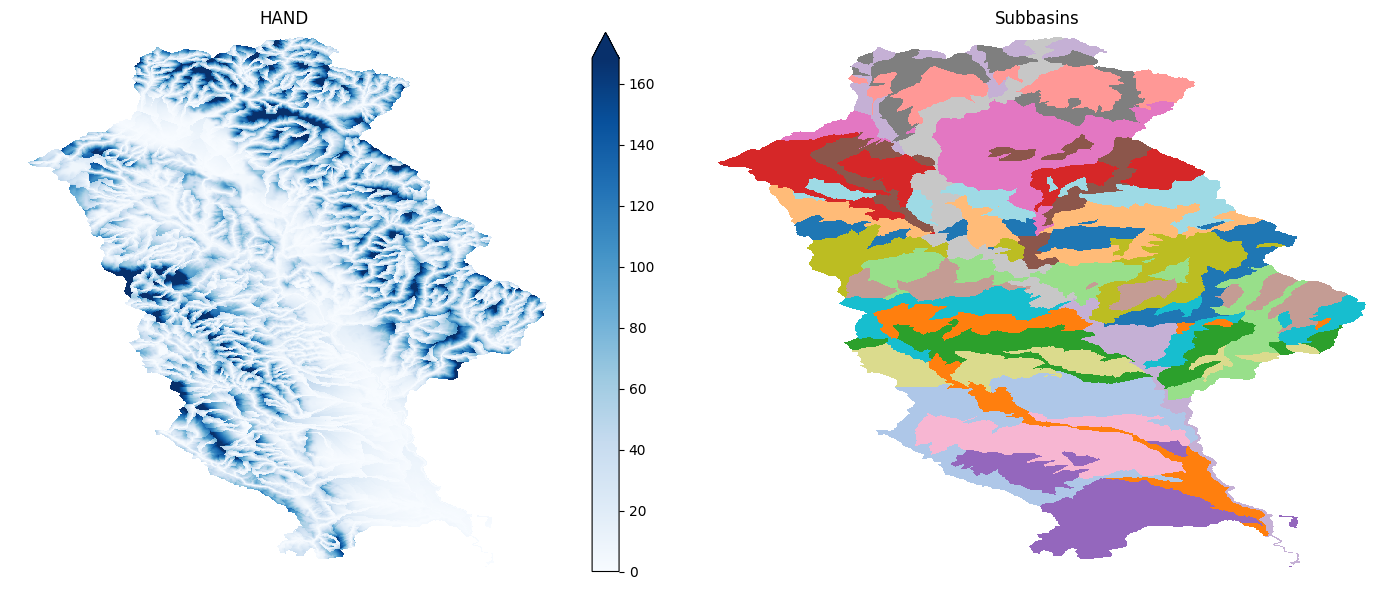

In [4]:
import numpy as np
from matplotlib.colors import ListedColormap

tab20 = plt.cm.tab20.colors
shuffled = list(tab20)
rng = np.random.default_rng(42)  # fixed seed so it's reproducible
rng.shuffle(shuffled)
cmap_shuffled = ListedColormap(shuffled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

hand.plot(ax=axes[0], cmap='Blues', add_colorbar=True, robust=True)
axes[0].set_title('HAND')
axes[0].set_axis_off()

subbasins.where(subbasins > 0).plot(ax=axes[1], cmap=cmap_shuffled, add_colorbar=False)
axes[1].set_title('Subbasins')
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

## Map valley floor

Run the core algorithm with default parameters. `map_valley_floor_detailed`
returns a `ValleyFloorDetailed` object with the final floor and all
intermediate outputs.

In [5]:
from vhs import map_valley_floor_detailed, Parameters

result = map_valley_floor_detailed(dem, hand, channel_network, subbasins, Parameters())

reaches: 760, tips: 455
headwaters filtered: 391


/Users/arthurkoehl/programs/pasternack/valley-floor/vhs/postprocess.py:39: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  filled.data = remove_small_holes(filled.data, area_threshold=num_cells)


## Visualize results

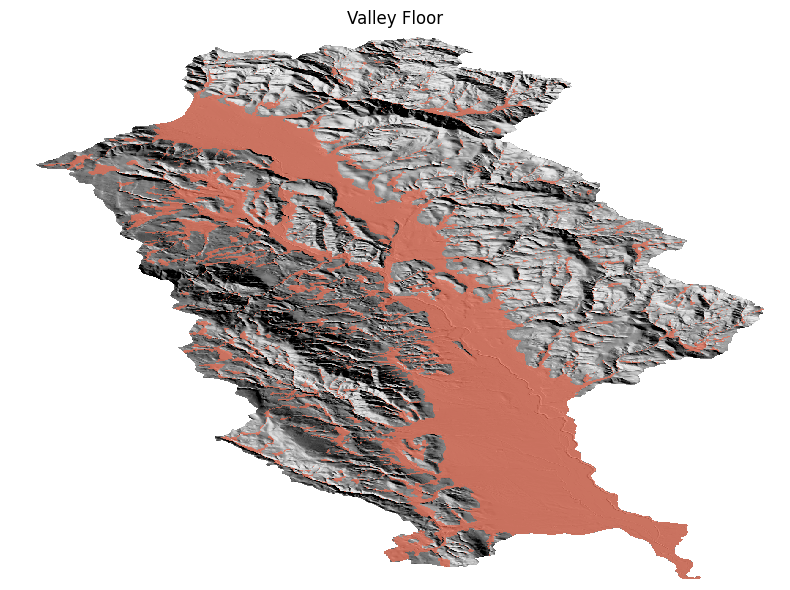

In [6]:
floor_masked = result.valley_floor.where(result.valley_floor == 1)

fig, ax = plt.subplots(figsize=(8, 6))
hs.plot(ax=ax, cmap='Greys_r', add_colorbar=False)
floor_masked.plot(ax=ax, cmap='Reds', add_colorbar=False, alpha=0.6)
ax.set_title('Valley Floor')
ax.set_axis_off()
plt.tight_layout()
plt.show()

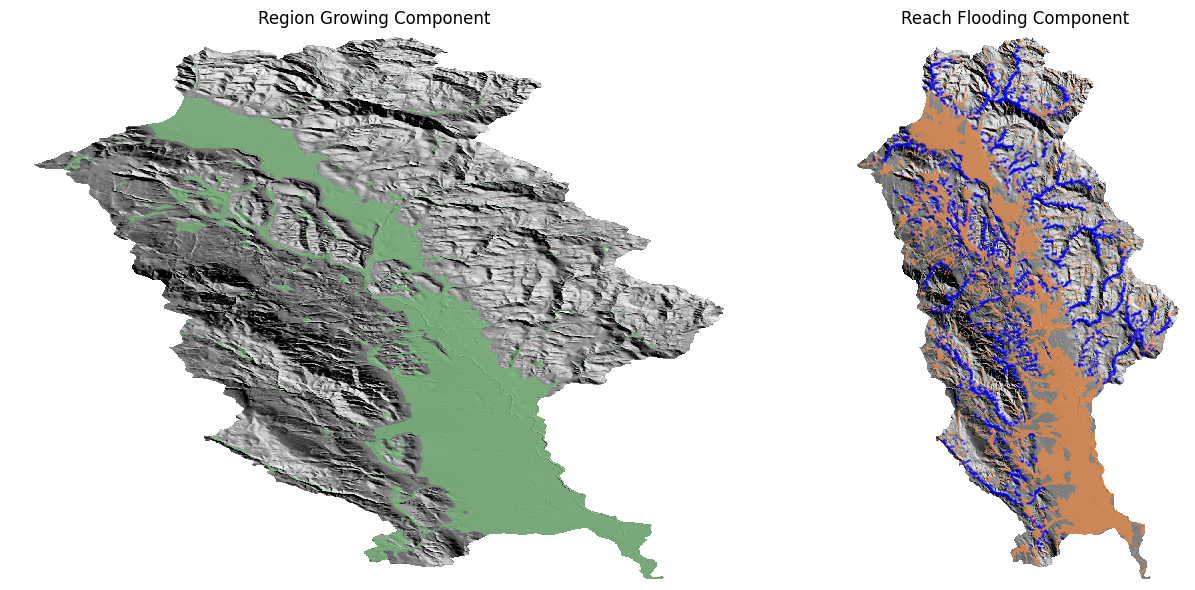

In [7]:
region_masked = result.region_floor.where(result.region_floor == 1)
flood_masked = result.flood_floor.where(result.flood_floor == 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

hs.plot(ax=axes[0], cmap='Greys_r', add_colorbar=False)
region_masked.plot(ax=axes[0], cmap='Greens', add_colorbar=False, alpha=0.6)
axes[0].set_title('Region Growing Component')
axes[0].set_axis_off()

hs.plot(ax=axes[1], cmap='Greys_r', add_colorbar=False)
flood_masked.plot(ax=axes[1], cmap='Oranges', add_colorbar=False, alpha=0.6)
axes[1].set_title('Reach Flooding Component')
axes[1].set_axis_off()
result.slope_break_pts.plot(ax=axes[1], color='blue', markersize=1, alpha=0.5)

plt.tight_layout()
plt.show()